In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix random seeds so results are (mostly) reproducible across runs
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1790614699.195256     113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790614699.241418     113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790614700.655390     113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 2. Create the toy dataset

A signal made of two sine waves with different frequencies plus Gaussian noise.
The slow component (period ≈ 100 steps) forces the model to use information from further back in time.

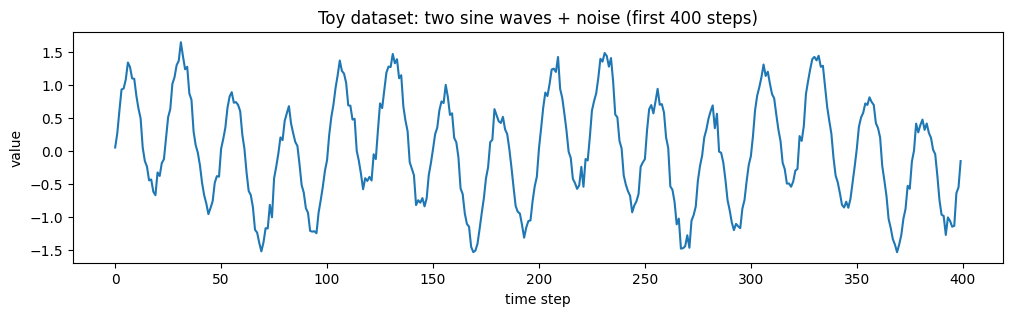

In [ ]:
N_POINTS = 3000                      # total length of the time series
t = np.arange(N_POINTS)

signal = (np.sin(2 * np.pi * t / 25)          # fast wave, period = 25 steps
          + 0.5 * np.sin(2 * np.pi * t / 100) # slow wave, period = 100 steps
          + 0.1 * np.random.randn(N_POINTS))  # noise

signal = signal.astype("float32")

# Visualise the first 400 points
plt.figure(figsize=(12, 3))
plt.plot(t[:400], signal[:400])
plt.title("Toy dataset: two sine waves + noise (first 400 steps)")
plt.xlabel("time step"); plt.ylabel("value")
plt.show()

## 3. Turn the series into supervised learning samples

Using a sliding window: input = `WINDOW` consecutive values, target = the next value.

RNN layers in Keras expect 3-D input with shape **`(batch, timesteps, features)`**. We have one feature per time step, so the last dimension is 1.

In [ ]:
WINDOW = 50   # how many past steps the model sees

def make_windows(series, window):
    # Slice a 1-D series into (X, y) pairs:
    #   X[i] = series[i : i+window]      -> the input sequence
    #   y[i] = series[i+window]          -> the value right after it
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    X = np.array(X)[..., np.newaxis]   # add feature axis -> (samples, window, 1)
    y = np.array(y)
    return X, y

# Chronological split (never shuffle time series before splitting,
# otherwise future information leaks into training)
train_end = int(0.70 * N_POINTS)
val_end   = int(0.85 * N_POINTS)

train_series = signal[:train_end]
val_series   = signal[train_end:val_end]
test_series  = signal[val_end:]

# Normalise using statistics from the TRAINING set only
mean, std = train_series.mean(), train_series.std()
norm = lambda s: (s - mean) / std
denorm = lambda s: s * std + mean

X_train, y_train = make_windows(norm(train_series), WINDOW)
X_val,   y_val   = make_windows(norm(val_series),   WINDOW)
X_test,  y_test  = make_windows(norm(test_series),  WINDOW)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  " y_test: ", y_test.shape)

X_train: (2050, 50, 1)  y_train: (2050,)
X_val:   (400, 50, 1)  y_val:   (400,)
X_test:  (400, 50, 1)  y_test:  (400,)


## 4. Shared training settings

In [ ]:
EPOCHS = 50
BATCH_SIZE = 32
UNITS = 32   # size of the hidden state h_t (same for both models for a fair comparison)

def get_callbacks():
    # Stop training when validation loss stops improving and roll back to the best weights
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                          restore_best_weights=True)]

## 5. Model 1 — Simple RNN

Architecture:
- `SimpleRNN(32)` reads the 50-step sequence and returns only the **final** hidden state $h_{50}$
- `Dense(1)` maps that hidden state to the predicted next value